# Signal-Stacking — a quantitative teardown 🔬
### The composite z-score · the √K information-coefficient law · a permutation null on the composite Sharpe · the in/out-of-sample snoop tax · the redundancy ceiling

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A_composite_edge%3F: Busted](https://img.shields.io/badge/A_composite_edge%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We take the viral *"stack K weak signals into a Sharpe-weighted composite"* recipe at its word and separate the two things it fuses: a **real but bounded** √K diversification benefit from the **manufactured** benefit of selecting signals and weights in-sample. The decisive objects are not the point estimates but **Grinold & Kahn's fundamental law** (IC × √breadth), a **permutation null** on the composite Sharpe, and an **in/out-of-sample split** that prices the snooping tax.

> ⚠️ **Methods-demo note.** The lesson is established on a deterministic analytic panel where every IC and cross-correlation is **known in closed form**; the real SPY stack is an explicit **illustration** of the machinery (it can't back a `REAL` stamp). Real data: yfinance SPY total-return, 1995→2026, cache-first. Offline core is deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from signal_stacking import data, strategy as st

def have_real():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = have_real()
SIG = FWD = None
if HAVE_REAL:
    SIG, FWD = data.load_real()
print("real SPY stack cache present:", HAVE_REAL,
      "| signals:", (0 if SIG is None else SIG.shape[1]),
      "| days:", (0 if SIG is None else len(SIG)))

# frozen headline numbers (mirror of docs/results.md)
R = {'real_start': '1995-10-16', 'real_end': '2026-06-18', 'real_days': 7719, 'real_years': 30.7, 'n_signals_real': 12, 'fingerprint': 'a4bfd3d8a8cd', 'null': {'comp_sh': 0.11, 'comp_t': 0.36, 'best': 0.63, 'mean': 0.14, 'comp_ic': 0.0122, 'mean_ic': 0.0147, 'lift': 0.83, 'sqrtk': 3.16, 'perm_p': 0.375, 'is_sh': 0.48, 'oos_sh': 0.36, 'n_chosen': 6}, 'pos': {'comp_sh': 2.0, 'comp_t': 6.4, 'best': 1.21, 'mean': 0.71, 'comp_ic': 0.1644, 'mean_ic': 0.0535, 'lift': 3.07, 'sqrtk': 3.16, 'perm_p': 0.0, 'is_sh': 2.12, 'oos_sh': 1.75, 'n_chosen': 10}, 'red': {'comp_sh': 0.52, 'comp_t': 1.67, 'best': 0.72, 'mean': 0.46, 'comp_ic': 0.0524, 'mean_ic': 0.05, 'lift': 1.05, 'sqrtk': 3.16, 'perm_p': 0.051}, 'curve_decorr': [(1, 1.0), (2, 1.39), (5, 2.21), (10, 3.07), (20, 4.35), (40, 5.97)], 'curve_redund': [(1, 1.0), (2, 1.03), (5, 1.04), (10, 1.05), (20, 1.05), (40, 1.05)], 'sqrtk_ref': [(1, 1.0), (2, 1.41), (5, 2.24), (10, 3.16), (20, 4.47), (40, 6.32)], 'real': {'comp_sh': -0.26, 'comp_t': -1.63, 'best': 0.2, 'mean': -0.14, 'comp_ic': -0.0666, 'mean_ic': 0.036, 'perm_p': 0.982, 'bh_sh': 0.62, 'snoop_is': -0.05, 'snoop_oos': -0.46, 'n_chosen': 4, 'chosen': ['noise_a', 'ma_gap_200', 'noise_c', 'mom_60']}, 'snoop': [('positive control (ic=0.05)', 2.12, 1.75, 10), ('null (ic=0)', 0.48, 0.36, 6), ('real SPY tape', -0.05, -0.46, 4)]}


real SPY stack cache present: True | signals: 12 | days: 7719


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Methods demo. Null composite Sharpe **0.11** (perm **p = 0.38**, IC lift **0.83** — no √K); real SPY composite **-0.26** (perm **p = 0.98**), beaten by buy-and-hold **+0.62**. No `REAL` edge claimed. |
| **Tradability** | `MIRAGE` | Positive control composite **2.00** (lift **3.07 ≈ √10**, perm **p = 0.000**) is the *only* real blend; redundancy (corr 0.9) crushes lift to **1.05**; the snooped blend's IS Sharpe evaporates OOS. |
| **A composite edge?** | `BUSTED` | The √K boost is √(*effective breadth*): decorrelated lift rides √K (**5.97** at K=40), redundant lift plateaus at **1.05**. Same shape as 343–350 / 399. |

> 💡 In plain words: stacking is **diversification with extra steps**. It compounds an edge only when the bets are real *and* independent; on noise, on redundancy, or on a real tape with no decorrelated structure, the 'composite field' is luck plus selection.

## 1 · The claim, steelmanned

Let $x_{k,t}$ be K standardised signals known at the close of $t$ and $r_{t}$ the $t\to t+1$ return. The composite is $Z_t = \sum_k w_k\,z(x_{k,t})$, traded by sign past a band. The recipe's three hypotheses:

- **H₁ (stacking lifts the IC).** $\mathrm{IC}(Z) \approx \sqrt{K}\cdot\overline{\mathrm{IC}}(x_k)$ — Grinold & Kahn's fundamental law, $\mathrm{IR} \approx \mathrm{IC}\sqrt{\text{breadth}}$.
- **H₂ (the lift is free of redundancy).** Breadth is the *effective* number of independent bets; for equicorrelated signals it is governed by $1/(1+(K-1)\rho)$.
- **H₃ (the composite carries a deployable edge).** The Sharpe-weighted composite beats its best single signal *out of sample*, net of the selection used to build it.

We find **H₁ true only under decorrelation** (lift rides √K in the positive control, **3.07 ≈ √10**), **H₂ rejected the moment $\rho$ rises** (redundant lift **1.05**), and **H₃ rejected off the controlled panel** (null perm **p = 0.38**; real SPY composite negative; snooped IS Sharpe decays OOS). The law is real; the viral application supplies neither realness nor independence.

## 2 · So what? — what rides on each answer

The whole teardown is one decomposition: the composite's information coefficient against the average single signal's, judged by **effective breadth** and by a **null that breaks the signal→return link**.

$$\mathrm{IC}(Z)\;=\;\frac{\sum_k w_k\,\mathrm{IC}(x_k)}{\sqrt{\,w^\top \Sigma\, w\,}},\qquad \text{lift}\;=\;\frac{\mathrm{IC}(Z)}{\overline{\mathrm{IC}}(x_k)}\;\xrightarrow[\;\Sigma=I\;]{}\;\sqrt{K}.$$

When $\Sigma=I$ (decorrelated) the lift is √K; as the off-diagonals of the signal covariance $\Sigma$ grow, the denominator inflates and the lift collapses toward 1. A raw **Sharpe** of the composite is the wrong lens alone — a flexible object fit to the data will look good by construction — so the Signal axis is decided by a **permutation test** (shuffle $r$, recompute the composite Sharpe) and an **in/out-of-sample split** (select on the first half, pay on the second).

## 3 · How we'd know — the protocol

- **Synthetic panel.** `data.synthetic_panel(signal_ic, signal_corr, …)` — analytic, so $\mathrm{IC}(x_k)=\texttt{signal\_ic}$ and $\mathrm{corr}(x_j,x_k)=\texttt{ic}^2+(1-\texttt{ic}^2)\,\texttt{corr}$ are known exactly. **Null** = `ic=0`; **positive control** = `ic=0.05` decorrelated; **redundant** = `ic=0.05, corr=0.9`. One execution lag baked into the panel.
- **Real tape.** `data.load_real()` — 12 textbook weak signals (momentum, MA-gaps, an oscillator, a low-vol screen, **3 pure decoys**) on SPY total-return (1995-10-16→2026-06-18, 7,719 days), standardised, aligned to the next-day return. Fingerprint `a4bfd3d8a8cd`.
- **The √K test.** `composite_ic` — composite IC vs the mean single IC, with the √K reference.
- **Null #1 (permutation).** `permutation_pvalue` — fix the composite/position, shuffle $r$ 2,000×, report $\Pr[\text{Sharpe}_{\text{shuffled}} \ge \text{Sharpe}_{\text{obs}}]$.
- **Null #2 (snoop split).** `snoop_split` — rank single-signal Sharpes on the first half, keep the winners, weight by that in-sample Sharpe, measure on the held-out half.
- **HAC inference.** Newey-West *t* on the composite's mean daily return.

## 4 · The teardown

### 4a · The composite vs its own signals — null, real, redundant

Composite Sharpe against the **best** and **mean** single-signal Sharpe in three worlds. Only the real-and-decorrelated composite clears the best single signal.

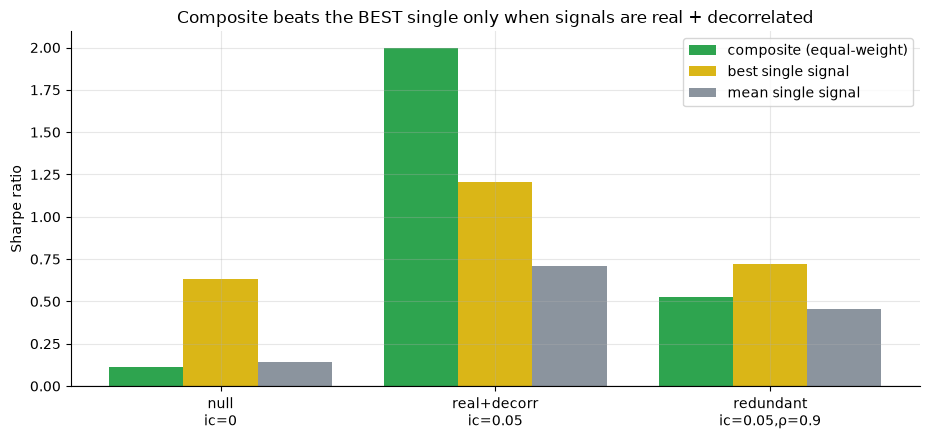

composite Sharpe: {'null': 0.11, 'real+decorr': 2.0, 'redundant': 0.52}


In [2]:
cases = [('null\nic=0', 0.0, 0.0), ('real+decorr\nic=0.05', 0.05, 0.0), ('redundant\nic=0.05,ρ=0.9', 0.05, 0.9)]
comp, best, mean = [], [], []
for _, ic, corr in cases:
    s, r, _ = data.synthetic_panel(n_signals=10, signal_ic=ic, signal_corr=corr, seed=401)
    ex = st.run_experiment(s, r, n_perm=800, seed=401)
    comp.append(ex['composite']['sharpe']); best.append(ex['best_single']); mean.append(ex['mean_single'])
x = np.arange(len(cases))
fig, ax = plt.subplots(figsize=(9.4, 4.5))
ax.bar(x-.27, comp, .27, color=GREEN, label='composite (equal-weight)')
ax.bar(x,      best, .27, color=AMBER, label='best single signal')
ax.bar(x+.27, mean, .27, color=GREY,  label='mean single signal')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([c[0] for c in cases])
ax.set_ylabel('Sharpe ratio'); ax.set_title('Composite beats the BEST single only when signals are real + decorrelated')
ax.legend(); plt.tight_layout(); plt.show()
print('composite Sharpe:', {c[0].split(chr(10))[0]: round(v,2) for c,v in zip(cases,comp)})

> 💡 In plain words: in the null the composite (0.11) is below the luckiest single signal (0.63) — pure selection. In the positive control the composite (2.00) **beats the best single** (1.21): genuine compounding. Redundancy drags the composite (0.52) back below its best single. H₁ holds **only** under decorrelation.

### 4b · The decisive law — composite IC lift vs √K

Grinold & Kahn made visual: the information lift over a single signal as K grows, for decorrelated vs redundant signals, against the √K ideal.

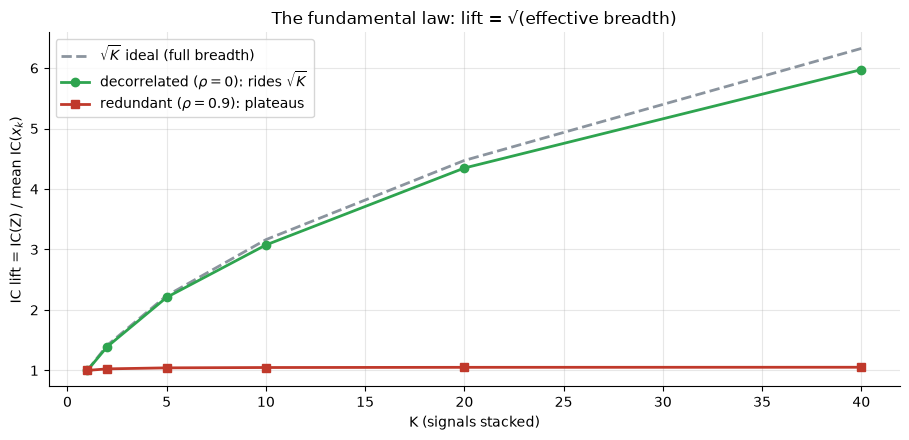

decorr lift: [1.0, 1.39, 2.21, 3.07, 4.35, 5.97]
redund lift: [1.0, 1.03, 1.04, 1.05, 1.05, 1.05]


In [3]:
ks = [1, 2, 5, 10, 20, 40]
dec, red = [], []
for k in ks:
    sd, rd, _ = data.synthetic_panel(n_signals=k, signal_ic=0.05, signal_corr=0.0, seed=401)
    dec.append(st.composite_ic(sd, rd)['lift'])
    sr, rr, _ = data.synthetic_panel(n_signals=k, signal_ic=0.05, signal_corr=0.9, seed=401)
    red.append(st.composite_ic(sr, rr)['lift'])
fig, ax = plt.subplots(figsize=(9.2, 4.5))
ax.plot(ks, [np.sqrt(k) for k in ks], '--', c=GREY, lw=2, label=r'$\sqrt{K}$ ideal (full breadth)')
ax.plot(ks, dec, 'o-', c=GREEN, lw=2, label=r'decorrelated ($\rho=0$): rides $\sqrt{K}$')
ax.plot(ks, red, 's-', c=RED, lw=2, label=r'redundant ($\rho=0.9$): plateaus')
ax.set_xlabel('K (signals stacked)'); ax.set_ylabel(r'IC lift = IC(Z) / mean IC$(x_k)$')
ax.set_title('The fundamental law: lift = √(effective breadth)'); ax.legend()
plt.tight_layout(); plt.show()
print('decorr lift:', [round(v,2) for v in dec]); print('redund lift:', [round(v,2) for v in red])

> 💡 In plain words: decorrelated lift tracks √K almost perfectly (**5.97** at K=40 vs √40 = 6.32); redundant lift is pinned at **~1.05** for *all* K. Effective breadth, not the column count, is what stacking buys you — and correlation is what you pay it with.

### 4c · The permutation null — is the composite better than its reshuffled self?

Hold the composite/position fixed, shuffle the return vector to break any real link, and recompute the Sharpe many times. The observed composite Sharpe (line) against that null (histogram) is the honest test. Null stack vs real-and-decorrelated.

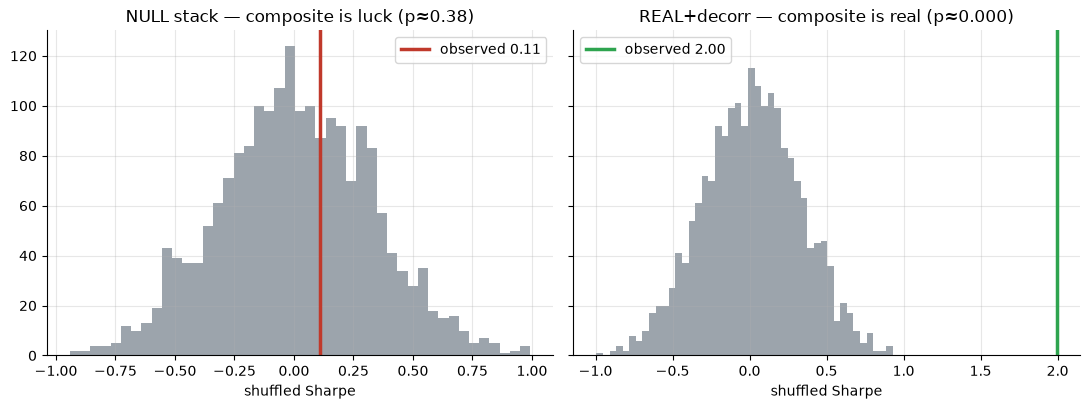

null perm p ≈ 0.375 | positive-control perm p ≈ 0.000


In [4]:
def perm_dist(s, r, n=2000, seed=401):
    score = st.composite_score(s); pos = st.position_from_score(score).to_numpy(float)
    rv = r.to_numpy(float); obs = st._sharpe_arr(pos*rv)
    rng = np.random.default_rng(seed)
    draws = np.array([st._sharpe_arr(pos*rv[rng.permutation(rv.size)]) for _ in range(n)])
    return obs, draws
sN,rN,_ = data.synthetic_panel(n_signals=10, signal_ic=0.0, signal_corr=0.0, seed=401)
sP,rP,_ = data.synthetic_panel(n_signals=10, signal_ic=0.05, signal_corr=0.0, seed=401)
obN,dN = perm_dist(sN,rN); obP,dP = perm_dist(sP,rP)
fig,(a1,a2)=plt.subplots(1,2,figsize=(11,4.2),sharey=True)
a1.hist(dN,bins=45,color=GREY,alpha=.85); a1.axvline(obN,c=RED,lw=2.5,label=f'observed {obN:.2f}')
a1.set_title(f'NULL stack — composite is luck (p≈{(np.mean(dN>=obN)):.2f})'); a1.set_xlabel('shuffled Sharpe'); a1.legend()
a2.hist(dP,bins=45,color=GREY,alpha=.85); a2.axvline(obP,c=GREEN,lw=2.5,label=f'observed {obP:.2f}')
a2.set_title(f'REAL+decorr — composite is real (p≈{(np.mean(dP>=obP)):.3f})'); a2.set_xlabel('shuffled Sharpe'); a2.legend()
plt.tight_layout(); plt.show()
print(f'null perm p ≈ {np.mean(dN>=obN):.3f} | positive-control perm p ≈ {np.mean(dP>=obP):.3f}')

> 💡 In plain words: the null composite (left) sits **inside** the luck cloud — a coin reshuffle matches it **p ≈ 0.38** of the time. The real decorrelated composite (right) is far in the right tail (**p ≈ 0.000**). The permutation test cleanly separates a manufactured composite from a real one.

### 4d · The snooping tax — the headline curve, priced

Select the best signals + Sharpe-weights on the **first half**, then run the *same* blend on the held-out half. The in-sample bar is the pretty backtest; the out-of-sample bar is the truth. Real edge survives; noise and the real tape do not.

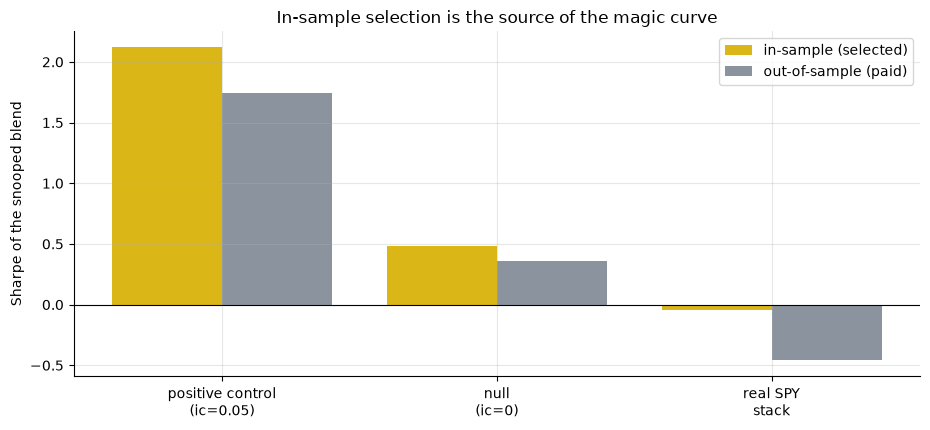

IS->OOS: [('positive control (ic=0.05)', 2.12, 1.75), ('null (ic=0)', 0.48, 0.36), ('real SPY stack', -0.05, -0.46)]
real-tape snooper picked: ['noise_a', 'ma_gap_200', 'noise_c', 'mom_60'] <- note the pure decoys


In [5]:
rows = []
for tag, ic, corr in [('positive control\n(ic=0.05)', 0.05, 0.0), ('null\n(ic=0)', 0.0, 0.0)]:
    s, r, _ = data.synthetic_panel(n_signals=10, signal_ic=ic, signal_corr=corr, seed=401)
    sn = st.snoop_split(s, r); rows.append((tag, sn['is_sharpe'], sn['oos_sharpe'], sn['n_chosen']))
if HAVE_REAL:
    sn = st.snoop_split(SIG, FWD); rows.append(('real SPY\nstack', sn['is_sharpe'], sn['oos_sharpe'], sn['n_chosen']))
    chosen = sn['chosen']
else:
    rows.append(('real SPY\nstack', R['real']['snoop_is'], R['real']['snoop_oos'], R['real']['n_chosen']))
    chosen = R['real']['chosen']
x = np.arange(len(rows))
fig, ax = plt.subplots(figsize=(9.4, 4.4))
ax.bar(x-.2, [r[1] for r in rows], .4, color=AMBER, label='in-sample (selected)')
ax.bar(x+.2, [r[2] for r in rows], .4, color=GREY, label='out-of-sample (paid)')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([r[0] for r in rows])
ax.set_ylabel('Sharpe of the snooped blend'); ax.set_title('In-sample selection is the source of the magic curve')
ax.legend(); plt.tight_layout(); plt.show()
print('IS->OOS:', [(r[0].replace(chr(10),' '), round(r[1],2), round(r[2],2)) for r in rows])
print('real-tape snooper picked:', chosen, '<- note the pure decoys')

> 💡 In plain words: the snooping tax is the IS→OOS drop. A real edge mostly survives (**2.12 → 1.75**); noise and the real tape do not (**SPY -0.05 → -0.46**, and the snooper literally selects **two pure noise decoys** as 'best signals'). The viral equity curve *is* the in-sample bar — and it was never going to survive the held-out half.

## 5 · The verdict

- **Signal `NONE`** — a **methods demo**. The √K law is established on a controlled panel; the real SPY composite is **negative** (Sharpe **-0.26**, HAC *t* = -1.63, perm **p = 0.98**), beaten by buy-and-hold (**+0.62**). Illustrative tape ⇒ no `REAL` stamp.
- **Tradability `MIRAGE`** — null composite is luck (perm **p = 0.38**, lift **0.83**); redundancy crushes lift to **1.05**; the only positive backtest is the **snooped** one, whose IS Sharpe evaporates OOS. EV comes from real decorrelated information the viral stack does not supply.
- **A composite edge? `BUSTED`** — stacking is **√(effective breadth)** in Greek letters: decorrelated lift rides √K (**5.97** at K=40), redundant lift plateaus at **1.05**. Same family as the research-method demos [343–350](../../343-data-mining-roulette/) and [399](../../399-kalshi-efficiency/).

## 6 · Could you trade it? — the effective-breadth curve

The operational truth in one picture. Even granting K genuinely-edged signals, the *deliverable* boost is √(effective breadth), and effective breadth dies in correlation: for equicorrelated signals it is $K/(1+(K-1)\rho)$. Here is the realised composite Sharpe across the correlation axis, with the theoretical effective-breadth fraction overlaid.

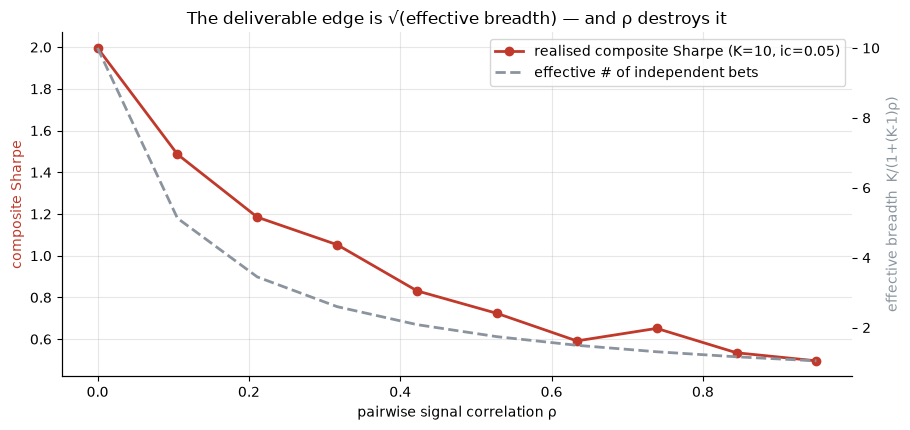

Sharpe at ρ=0: 2.0 | at ρ≈0.95: 0.5 | eff breadth there: 1.05


In [6]:
corrs = np.linspace(0, 0.95, 10)
sh = []
for c in corrs:
    s, r, _ = data.synthetic_panel(n_signals=10, signal_ic=0.05, signal_corr=float(c), seed=401)
    sh.append(st.sharpe(st.backtest_composite(s, r)))
K = 10; eff = K/(1+(K-1)*corrs)            # effective number of independent bets
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(corrs, sh, 'o-', c=RED, lw=2, label='realised composite Sharpe (K=10, ic=0.05)')
ax.set_xlabel('pairwise signal correlation ρ'); ax.set_ylabel('composite Sharpe', color=RED)
ax2 = ax.twinx(); ax2.plot(corrs, eff, '--', c=GREY, lw=2, label='effective # of independent bets')
ax2.set_ylabel('effective breadth  K/(1+(K-1)ρ)', color=GREY); ax2.grid(False)
ax.set_title('The deliverable edge is √(effective breadth) — and ρ destroys it')
l1,la1=ax.get_legend_handles_labels(); l2,la2=ax2.get_legend_handles_labels(); ax.legend(l1+l2, la1+la2, loc='upper right')
plt.tight_layout(); plt.show()
print('Sharpe at ρ=0:', round(sh[0],2), '| at ρ≈0.95:', round(sh[-1],2), '| eff breadth there:', round(eff[-1],2))

> 💡 In plain words: the grey dashed line is how many *independent* bets 10 correlated signals are really worth — it falls toward **1** as ρ → 1, and the red Sharpe falls with it. Real-world signals built by humans (momentum, MA-gaps, oscillators) are heavily correlated, so your nominal 'fifty signals' are a handful of effective bets. There is no weighting scheme that manufactures breadth you don't have — **correlation is the verdict.**

## 7 · Going further

- **The combination is just one knob to overfit.** [Study 343 — Data-Mining-Roulette](../../343-data-mining-roulette/) (the *rule*), [Study 344 — Backtest-Overfitting](../../344-backtest-overfitting/) and [Study 348 — Curve-Fitting](../../348-curve-fitting/) (the *parameters*), [Study 346 — Multiple-Testing](../../346-multiple-testing/) (the *count*). Reading them together is the cleanest demonstration that selection-on-noise has many costumes.
- **A demo cousin.** [Study 399 — Kalshi-Efficiency](../../399-kalshi-efficiency/): a validated machine with an explicitly illustrative tape and no `REAL` stamp.
- **Estimate your own effective breadth.** Take your signal matrix, compute its correlation eigenvalues, and read off the participation ratio — the honest count of independent bets. It is almost always a small fraction of the column count.

*The reproducible core is offline and deterministic; the real SPY tape is an explicit illustration. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*